In [1]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from stepmix.stepmix import StepMix
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity


import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv('C:/Users/xavis/Xavier/Benestar-e/DATA/DADES_EXCEL_TOTS_v05.csv', sep=';')
print(df.shape)
df.head()

(846, 261)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
0,1,1,18,1,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,8

In [3]:
df['descans'] = df['descans'].replace(2, 0)

print(df.shape)
print(df['descans'].value_counts())
df.head()

(846, 261)
descans
1.0    376
0.0    372
Name: count, dtype: int64


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
0,1,1,18,1,1.0,1,4,2,NaN,NaN,NaN,NaN,1.0,1.0,1,0,0,0,0,21.0,0,1,0,0,0,0,0,1.0,0,0,1,0,2,1,0,1,0,0,0,0,1,0,0,0,0,0,1,3,2,6,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0,0.0,4,4,4,3,4,4,5,4,5,5,3,4,3,4,5,4,5,5,5,5,3,3,4,5,4,2,4,5,5,4,5,4,4,44,38,28,27,137,2,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,8

In [4]:
TASS = df[df['GRUP'].isin([3])]
print(TASS.shape)
TASS.head()

(199, 261)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
7,8,3,15,2,4.0,1,5,3,1.0,5.0,2.0,1.0,NaN,NaN,0,0,0,0,0,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40.0,41.0,38.0,35.0,0.0,0.0,0.0,0.0,0,0.0,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,50,44,40,30,164,3,99.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,6.0,5.0,6.0,1.0,1.0,6.0,6.0,6.0,0.0,0.0,6.0,1.4,0.50,6.00,2.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,7.0,7.0,6.0,6.0,32.0,90

In [5]:
TASS['GRUP'].value_counts()

GRUP
3    199
Name: count, dtype: int64

In [6]:
# Usando dropna() para Cluster_PAS
TASS = TASS.dropna(subset=['Cluster_PAS'])
print(f"Forma final: {TASS.shape}")
print("Distribución de clusters:")
print(TASS['Cluster_PAS'].value_counts())

print(TASS.shape)
TASS.head()

Forma final: (185, 261)
Distribución de clusters:
Cluster_PAS
0.0    130
1.0     55
Name: count, dtype: int64
(185, 261)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic,…)_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic,…)_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,Tranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,nacionalitat_DICO,edat_categorica_REDUIDA,consum-DROGUES-TRANQUILITZANTS,FACTOR1_BENESTAR,consum-DROGUES,Cluster_Benestar_Workers,Cluster_PDI,Cluster_PAS,risc_alcohol,FACTOR1_BENESTAR_N100,Cluster_Estudiants
7,8,3,15,2,4.0,1,5,3,1.0,5.0,2.0,1.0,NaN,NaN,0,0,0,0,0,NaN,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,40.0,41.0,38.0,35.0,0.0,0.0,0.0,0.0,0,0.0,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,50,44,40,30,164,3,99.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,6.0,5.0,6.0,1.0,1.0,6.0,6.0,6.0,0.0,0.0,6.0,1.4,0.50,6.00,2.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,7.0,7.0,6.0,6.0,32.0,90

In [7]:
TASS.isna().sum().sum()

6375

In [8]:
TASS['genere'].unique()
TASS['genere'] = TASS['genere'].replace({1: 0, 2: 1}) ## 1==mujer, 0==hombre

print(TASS['genere'].value_counts())

genere
1    137
0     48
Name: count, dtype: int64


In [9]:
TASS.columns.tolist()

['ID',
 'GRUP',
 'record_id',
 'genere',
 'edat_categorica',
 'nacionalitat',
 'salud',
 'situacio_economica',
 'contracte_uvic',
 'antiguitat',
 'pdi_pas',
 'centre_pas',
 'centre_pdi_estudiant',
 'centre_estudiant',
 'estudis_uvic___1',
 'estudis_uvic___2',
 'estudis_uvic___3',
 'estudis_uvic___4',
 'estudis_uvic___5',
 'graus',
 'curs___1',
 'curs___2',
 'curs___3',
 'curs___4',
 'curs___5',
 'curs___6',
 'curs___7',
 'situacio_laboral',
 'BSI1',
 'BSI2',
 'BSI3',
 'BSI4',
 'BSI5',
 'BSI6',
 'BSI7',
 'BSI8',
 'BSI9',
 'BSI10',
 'BSI11',
 'BSI12',
 'BSI13',
 'BSI14',
 'BSI15',
 'BSI16',
 'BSI17',
 'BSI18',
 'BSI_Somatització_PD',
 'BSI_Depresió_PD',
 'BSI_Ansietat_PD',
 'BSI_IGS_PD',
 'BSI_Somatització_PT',
 'BSI_Depresió_PT',
 'BSI_Ansietat_PT',
 'BSI_IGS_PT',
 'BSI_Somatització_Clínic',
 'BSI_Depresió_Clínic',
 'BSI_Ansietat_Clínic',
 'BSI_IGS_Clínic',
 'Pregunta BSI_17_Clínic_suïcidi',
 'BSI_Clínic_suïcidi',
 'sseit1',
 'sseit2',
 'sseit3',
 'sseit4',
 'sseit5',
 'sseit6',
 'sseit

In [10]:
TASS.rename(columns={'FACTOR1_BENESTAR_N100': 'Well-being Emotional Factor Five'}, inplace=True)

In [11]:
sociodemo = ['ID',
 'genere',
 'edat_categorica_REDUIDA',
 'nacionalitat_DICO',
 'salud',
 'situacio_economica',
 'esport',
 'hores_fisic',
 'risc_alcohol',
 'Tranquil·litzants/pastilles per dormir',
 'consum-DROGUES',
 'fumador',
 'n_cigarretes_dia',
 'son',
 'descans',
 'Cluster_PAS',
 'Well-being Emotional Factor Five']

In [12]:
TASS = TASS[sociodemo]
print(TASS.shape)
TASS.head()

(185, 17)


,ID,genere,edat_categorica_REDUIDA,nacionalitat_DICO,salud,situacio_economica,esport,hores_fisic,risc_alcohol,Tranquil·litzants/pastilles per dormir,consum-DROGUES,fumador,n_cigarretes_dia,son,descans,Cluster_PAS,Well-being Emotional Factor Five
7,8,1,3.0,1,5,3,NaN,NaN,0.0,2.0,0.0,1.0,0.0,2.0,1.0,1.0,91.636611
8,9,0,3.0,1,4,2,2.0,0.0,0.0,2.0,0.0,3.0,3.0,2.0,0.0,0.0,30.317449
12,13,0,3.0,1,4,2,2.0,0.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,0.0,39.634331
33,34,0,3.0,1,4,2,2.0,0.0,0.0,2.0,0.0,1.0,0.0,2.0,0.0,0.0,39.634331
34,35,1,3.0,1,5,3,1.0,5.0,0.0,2.0,0.0,3.0,4.0,2.0,1.0,0.0,63.534323


In [13]:
# deleting rows with any missing values in the entire DataFrame
TASS = TASS.dropna()
print(f"New shape: ", TASS.shape)
print(TASS.isna().sum())


New shape:  (180, 17)
ID                                        0
genere                                    0
edat_categorica_REDUIDA                   0
nacionalitat_DICO                         0
salud                                     0
situacio_economica                        0
esport                                    0
hores_fisic                               0
risc_alcohol                              0
Tranquil·litzants/pastilles per dormir    0
consum-DROGUES                            0
fumador                                   0
n_cigarretes_dia                          0
son                                       0
descans                                   0
Cluster_PAS                               0
Well-being Emotional Factor Five          0
dtype: int64


In [14]:
TASS['Cluster_PAS'].value_counts()

Cluster_PAS
0.0    127
1.0     53
Name: count, dtype: int64

In [15]:
for col in TASS.columns:
    print(f"{col}: {TASS[col].nunique()} categories")

ID: 180 categories
genere: 2 categories
edat_categorica_REDUIDA: 3 categories
nacionalitat_DICO: 2 categories
salud: 5 categories
situacio_economica: 4 categories
esport: 2 categories
hores_fisic: 6 categories
risc_alcohol: 2 categories
Tranquil·litzants/pastilles per dormir: 2 categories
consum-DROGUES: 2 categories
fumador: 3 categories
n_cigarretes_dia: 5 categories
son: 2 categories
descans: 2 categories
Cluster_PAS: 2 categories
Well-being Emotional Factor Five: 179 categories


In [16]:
from scipy.stats import shapiro, normaltest, kstest
import pandas as pd

print("Normality test for Well-being Emotional Factor Five:")
# Supón que tu DataFrame es workers y la variable es Well-being Emotional Factor Five
x = TASS["Well-being Emotional Factor Five"].dropna()

# # Shapiro-Wilk
# stat, p = shapiro(x)
# print(f"Shapiro-Wilk → estadístico={stat:.3f}, p={p:.3f}")

# # D’Agostino & Pearson
# stat2, p2 = normaltest(x)
# print(f"D’Agostino-Pearson → estadístico={stat2:.3f}, p={p2:.3f}")

# Kolmogorov-Smirnov
from scipy.stats import norm
stat3, p3 = kstest(x, 'norm', args=(x.mean(), x.std()))
print(f"Kolmogorov-Smirnov → estadístico={stat3:.3f}, p={p3:.3f}")


Normality test for Well-being Emotional Factor Five:
Kolmogorov-Smirnov → estadístico=0.043, p=0.874


CÓDIGOS ACTUALIZADOS:
genere                                   → B (Dicotómica auténtica)
edat_categorica_REDUIDA                  → D (Ordinal/rangs)
nacionalitat_DICO                        → B (Dicotómica auténtica)
salud                                    → D (Ordinal/rangs)
situacio_economica                       → D (Ordinal/rangs)
esport                                   → B (Dicotómica auténtica)
hores_fisic                              → D (Ordinal/rangs)
risc_alcohol                             → C (Dicotómica artificial)
Tranquil·litzants/pastilles per dormir   → B (Dicotómica auténtica)
consum-DROGUES                           → B (Dicotómica auténtica)
fumador                                  → A (Nominal 3+ cat)
n_cigarretes_dia                         → D (Ordinal/rangs)
son                                      → B (Dicotómica auténtica)
descans                                  → B (Dicotómica auténtica)
Well-being Emotional Factor Five         → F (Continua NO normal)


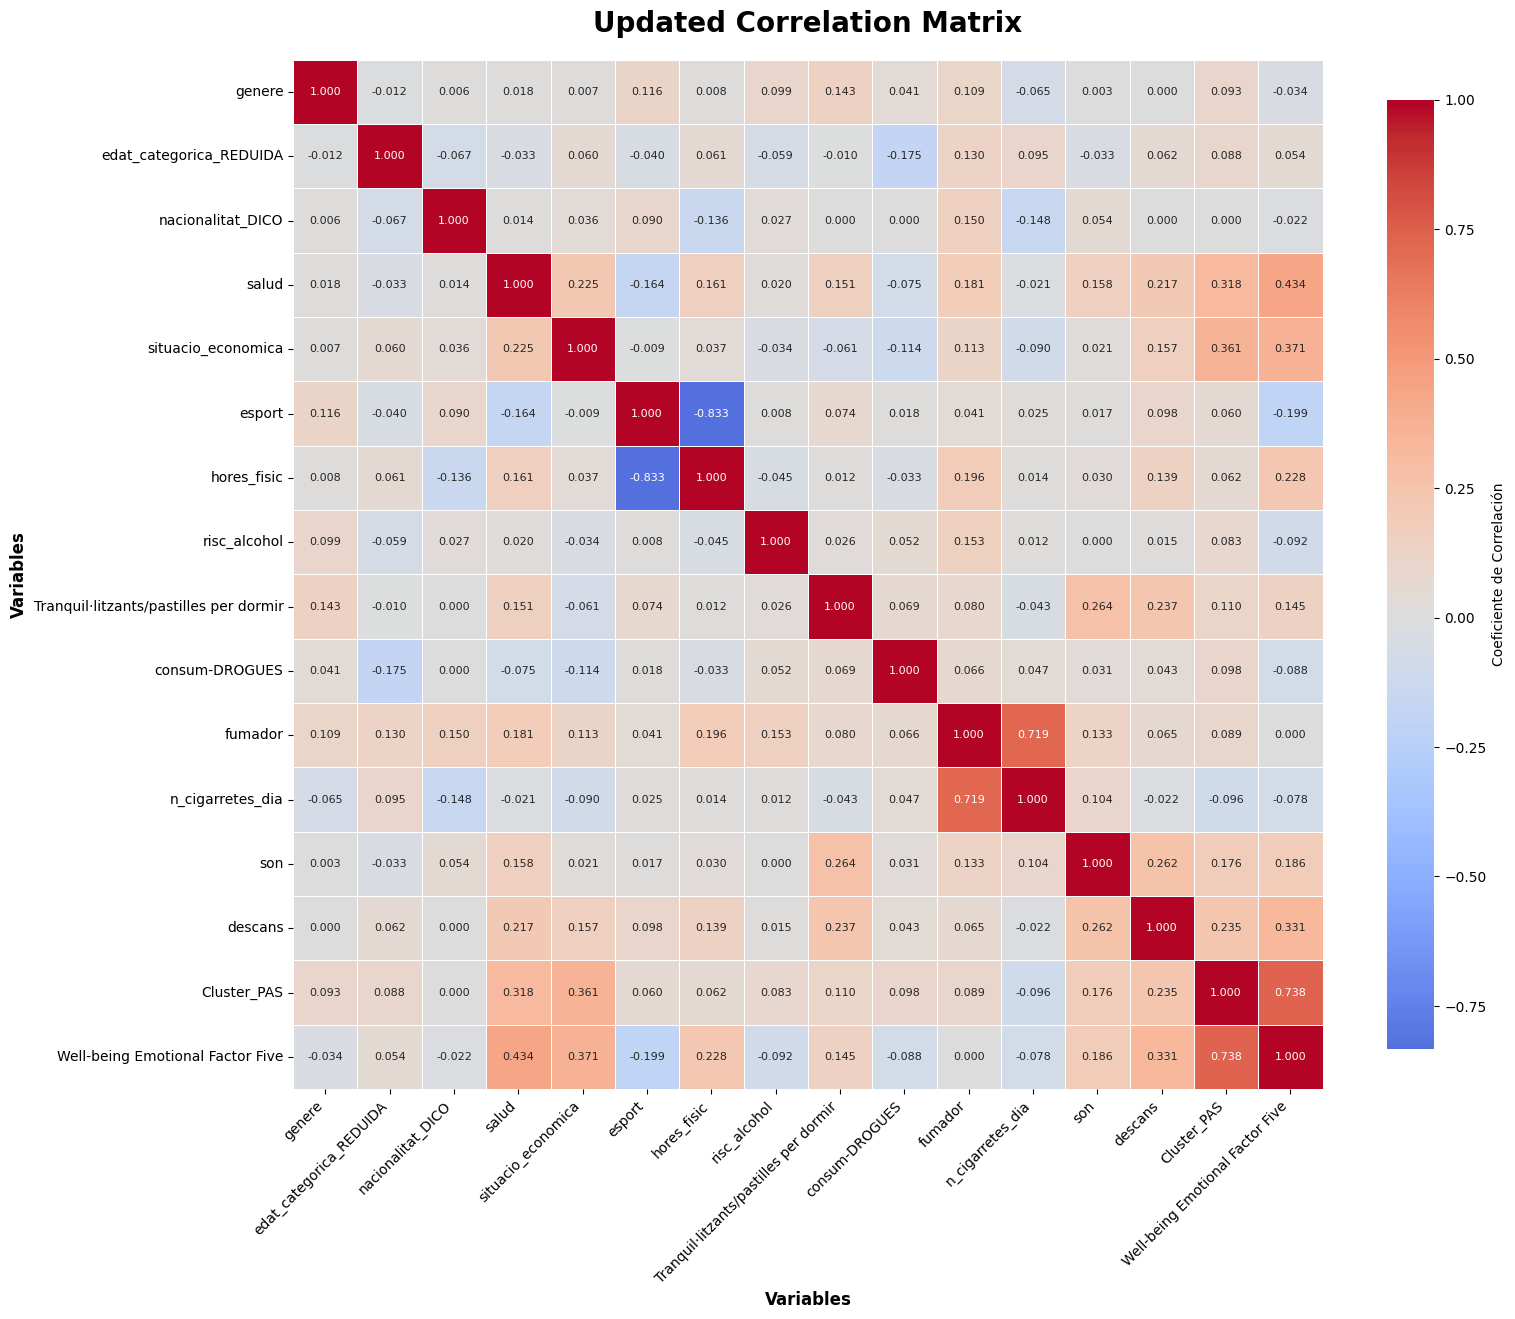


UPDATED CORRELATION MATRIX:
                                        genere  edat_categorica_REDUIDA  \
genere                                   1.000                   -0.012   
edat_categorica_REDUIDA                 -0.012                    1.000   
nacionalitat_DICO                        0.006                   -0.067   
salud                                    0.018                   -0.033   
situacio_economica                       0.007                    0.060   
esport                                   0.116                   -0.040   
hores_fisic                              0.008                    0.061   
risc_alcohol                             0.099                   -0.059   
Tranquil·litzants/pastilles per dormir   0.143                   -0.010   
consum-DROGUES                           0.041                   -0.175   
fumador                                  0.109                    0.130   
n_cigarretes_dia                        -0.065                    0.095

In [17]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr, pointbiserialr, chi2_contingency
from scipy.stats.contingency import association
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from scipy.stats import kendalltau

# --- Función Phi de Pearson (para dicotómicas auténticas)
def phi_pearson(x, y):
    """Coeficiente Phi de Pearson para dos dicotómicas auténticas"""
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    return np.sqrt(chi2 / n)

# --- Función Tetracórica (aproximación para dicotómicas artificiales)
def tetrachorica_aprox(x, y):
    """Aproximación de correlación tetracórica usando transformación"""
    try:
        # Convertir a 0/1 si no lo están
        x_bin = (x == x.max()).astype(int)
        y_bin = (y == y.max()).astype(int)
        # Usar phi como aproximación
        return phi_pearson(x_bin, y_bin)
    except:
        return np.nan

# --- Función Biseriada (aproximación)
def biserial_aprox(cont, dico):
    """Aproximación de correlación biseriada"""
    try:
        # Usar point-biserial como aproximación mejorada
        return pointbiserialr(dico, cont)[0]
    except:
        return np.nan

# --- Función Coeficiente de Contingencia
def coeficiente_contingencia(x, y):
    """Coeficiente de contingencia para variables nominales"""
    try:
        tabla = pd.crosstab(x, y)
        chi2 = chi2_contingency(tabla)[0]
        n = tabla.sum().sum()
        return np.sqrt(chi2 / (chi2 + n))
    except:
        return np.nan

def kruskal_wallis_effect_size(nominal, continua):
    """
    Calcula test de Kruskal-Wallis y su tamaño del efecto (epsilon-cuadrado)
    para nominal vs continua cuando no hay normalidad
    """
    try:
        # Crear grupos basados en la variable nominal
        grupos = [continua[nominal == categoria].dropna() for categoria in nominal.unique()]
        
        # Filtrar grupos vacíos
        grupos = [grupo for grupo in grupos if len(grupo) > 0]
        
        if len(grupos) < 2:
            return np.nan
        
        # Test de Kruskal-Wallis
        h_stat, p_valor = kruskal(*grupos)
        
        # Calcular epsilon-cuadrado (tamaño del efecto para Kruskal-Wallis)
        n_total = sum(len(grupo) for grupo in grupos)
        epsilon_squared = (h_stat - len(grupos) + 1) / (n_total - len(grupos))
        
        # Asegurar que está entre 0 y 1
        epsilon_squared = max(0, min(1, epsilon_squared))
        
        return epsilon_squared
        
    except Exception as e:
        return np.nan

# --- Función principal ACTUALIZADA según tu tabla
def matriz_correlacion_mixta(df, codigos):
    """
    Matriz de correlaciones heterogéneas basada en tipos de variables
    codigos = {'var1':'A','var2':'B',...}
    A = Nominal 3+ categorías
    B = Dicotómica auténtica  
    C = Dicotómica artificial
    D = Ordinal/rangs
    E = Continua normal
    F = Continua NO normal
    """

    vars_all = [v for v in df.columns if v in codigos]
    n = len(vars_all)
    
    corr_matrix = pd.DataFrame(np.zeros((n,n)), index=vars_all, columns=vars_all)
    metodo_matrix = pd.DataFrame('', index=vars_all, columns=vars_all)

    for i, var1 in enumerate(vars_all):
        for j, var2 in enumerate(vars_all):

            if i == j:
                corr_matrix.loc[var1, var2] = 1.0
                metodo_matrix.loc[var1, var2] = "Diagonal"
                continue

            x, y = df[var1], df[var2]
            t1, t2 = codigos[var1], codigos[var2]

            try:
                # --- CLAVES COMBINADAS (ordenar alfabéticamente) ---
                combo = ''.join(sorted([t1, t2]))

                # --- Aplicación según tu tabla ---
                if combo == "CC":  # Dicotómica artificial ↔ Dicotómica artificial
                    r = tetrachorica_aprox(x, y)
                    metodo = "Tetracórica"

                elif combo == "CE":  # Dicotómica artificial ↔ Continua normal
                    r = biserial_aprox(y if t2 == 'E' else x, x if t2 == 'E' else y)
                    metodo = "Biseriada"

                elif combo == "BB":  # Dicotómica auténtica ↔ Dicotómica auténtica
                    r = phi_pearson(x, y)
                    metodo = "Phi de Pearson"

                elif combo == "BE":  # Dicotómica auténtica ↔ Continua normal
                    r = pointbiserialr(x if t1 == 'B' else y, y if t1 == 'B' else x)[0]
                    metodo = "Point-biserial"

                elif combo == "EE":  # Continua normal ↔ Continua normal
                    r, _ = pearsonr(x, y)
                    metodo = "Pearson"

                elif combo == "EF":  # Continua normal ↔ Continua NO normal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "FF":  # Continua NO normal ↔ Continua NO normal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "DD":  # Ordinal ↔ Ordinal
                    r, _ = kendalltau(x, y)
                    metodo = "Kendall-Tau"

                elif combo == "BD":  # Dicotómica auténtica ↔ Ordinal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "CD":  # Dicotómica artificial ↔ Ordinal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "AD":  # Nominal ↔ Ordinal
                    r = coeficiente_contingencia(x, y)
                    metodo = "Coeficiente de contingencia"

                elif combo == "AA":  # Nominal ↔ Nominal
                    r = association(pd.crosstab(x, y), method="cramer")
                    metodo = "Cramer's V"

                elif combo == "AF":  # Nominal ↔ Continua NO normal
                    r = kruskal_wallis_effect_size(x if t1 == 'A' else y, y if t1 == 'A' else x)
                    metodo = "Kruskal-Wallis"

                elif combo == "AE":  # Nominal ↔ Continua normal
                    r = kruskal_wallis_effect_size(x if t1 == 'A' else y, y if t1 == 'A' else x)
                    metodo = "Kruskal-Wallis"

                elif combo == "BC":  # Dicotómica auténtica ↔ Dicotómica artificial
                    r = phi_pearson(x, y)
                    metodo = "Phi de Pearson"

                elif combo == "AB":  # Nominal ↔ Dicotómica auténtica
                    r = association(pd.crosstab(x, y), method="cramer")
                    metodo = "Chi-cuadrado/Cramer's V"

                elif combo == "AC":  # Nominal ↔ Dicotómica artificial
                    r = association(pd.crosstab(x, y), method="cramer")
                    metodo = "Cramer's V"

                elif combo == "BF":  # Dicotómica auténtica ↔ Continua NO normal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "CF":  # Dicotómica artificial ↔ Continua NO normal
                    r = biserial_aprox(y if t2 == 'F' else x, x if t2 == 'F' else y)
                    metodo = "Biseriada/Mann-Whitney"

                elif combo == "DE":  # Ordinal ↔ Continua normal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                elif combo == "DF":  # Ordinal ↔ Continua NO normal
                    r, _ = spearmanr(x, y)
                    metodo = "Spearman"

                else:
                    r = np.nan
                    metodo = "No definido"

            except:
                r = np.nan
                metodo = "Error"

            corr_matrix.loc[var1, var2] = r
            metodo_matrix.loc[var1, var2] = metodo

    # VISUALIZACIÓN
    plt.figure(figsize=(16, 14))
    
    sns.heatmap(
        corr_matrix.astype(float), 
        cmap='coolwarm', 
        center=0,
        annot=True, 
        fmt='.3f',
        annot_kws={'size': 8},
        square=True, 
        linewidths=0.5,
        cbar_kws={"shrink": .8, "label": "Coeficiente de Correlación"}
    )
    
    plt.title("Updated Correlation Matrix", fontsize=20, fontweight='bold', pad=20)
    plt.xlabel("Variables", fontsize=12, fontweight='bold')
    plt.ylabel("Variables", fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

    return corr_matrix, metodo_matrix

codigos_actualizados = {
    "genere": "B",                           # Dicotómica auténtica
    "edat_categorica_REDUIDA": "D",          # Ordinal 3 cat
    "nacionalitat_DICO": "B",                # Dicotómica auténtica
    "salud": "D",                           # Ordinal 5 cat
    "situacio_economica": "D",              # Ordinal 4 cat
    "esport": "B",                          # Dicotómica auténtica
    "hores_fisic": "D",                     # Ordinal 6 cat
    "risc_alcohol": "C",                    # Dicotómica artificial
    "Tranquil·litzants/pastilles per dormir": "B",  # Dicotómica auténtica
    "consum-DROGUES": "B",                  # Dicotómica auténtica
    "fumador": "A",                         # Nominal 3 cat
    "n_cigarretes_dia": "D",               # Ordinal 4 cat
    "son": "B",                            # Dicotómica auténtica
    "descans": "B",                        # Dicotómica auténtica
    "Well-being Emotional Factor Five": "F",          # Continua NO normal
    "Cluster_PAS": "C"                     # Dicotómica artificial
}

print("CÓDIGOS ACTUALIZADOS:")
for var, codigo in codigos_actualizados.items():
    tipo_desc = {
        'A': 'Nominal 3+ cat',
        'B': 'Dicotómica auténtica', 
        'C': 'Dicotómica artificial',
        'D': 'Ordinal/rangs',
        'E': 'Continua normal',
        'F': 'Continua NO normal'
    }
    print(f"{var:<40} → {codigo} ({tipo_desc[codigo]})")

# --- EJECUTAR ANÁLISIS ACTUALIZADO ---
print("\n" + "="*80)
print("UPDATED CORRELATION MATRIX")
print("="*80)

# Filtrar solo las variables que están en el diccionario
variables_analizar = [var for var in TASS.columns if var in codigos_actualizados and var != 'ID']
df_filtrado = TASS[variables_analizar]

corr_matrix_actualizada, metodos_actualizados = matriz_correlacion_mixta(df_filtrado, codigos_actualizados)

print("\nUPDATED CORRELATION MATRIX:")
print(corr_matrix_actualizada.round(3))

print("\nUPDATED METHODS USED:")
print(metodos_actualizados)

In [18]:
# ================ DESCRIPTIVE ANALYSIS BY CLUSTERS ================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association
import warnings
warnings.filterwarnings('ignore')

vars_sociodemo = [col for col in TASS.columns if col not in ['ID']]

print(f"\n1. CLUSTERS DISTRIBUTIONS:")
print(TASS['Cluster_PAS'].value_counts().sort_index())
print(f"Percentages:")
print(TASS['Cluster_PAS'].value_counts(normalize=True).sort_index().round(3) * 100)




1. CLUSTERS DISTRIBUTIONS:
Cluster_PAS
0.0    127
1.0     53
Name: count, dtype: int64
Percentages:
Cluster_PAS
0.0    70.6
1.0    29.4
Name: proportion, dtype: float64


In [19]:
# ================ TESTS OF ESTADISTIC ASSOCIATIONS ================

from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association
import pandas as pd

def calcular_v_cramer(chi2, n, min_dim):
    """Calcula la V de Cramér"""
    return np.sqrt(chi2 / (n * (min_dim - 1)))

resultados_tests = []

print("\n" + "=" * 80)
print(" TESTS OF ESTADISTIC ASSOCIATIONS")
print("=" * 80)

for variable in vars_sociodemo:
    if variable != 'Cluster_PAS':
        print(f"\nAnalizando: {variable}")

        # Crear tabla de contingencia (sin margins)
        tabla = pd.crosstab(TASS[variable], TASS['Cluster_PAS'])

        # Test Chi-cuadrado
        try:
            chi2, p_valor, dof, expected = chi2_contingency(tabla)
            n = tabla.sum().sum()
            min_dim = min(tabla.shape)
            v_cramer = calcular_v_cramer(chi2, n, min_dim)

            # Determinar significancia
            significativo = p_valor < 0.05

            # Interpretación de V de Cramér
            if v_cramer < 0.1:
                fuerza = "Very weak"
            elif v_cramer < 0.3:
                fuerza = "Weak"
            elif v_cramer < 0.5:
                fuerza = "Moderate"
            else:
                fuerza = "Strong"

            print(f"  Chi² = {chi2:.4f}, p-valor = {p_valor:.6f}")
            print(f"  V de Cramér = {v_cramer:.4f} ({fuerza})")
            print(f"  Significativo: {'SÍ' if significativo else 'NO'}")

            resultados_tests.append({
                'Variable': variable,
                'Chi2': chi2,
                'p_valor': p_valor,
                'V_Cramer': v_cramer,
                'Significativo': significativo,
                'Fuerza_Asociacion': fuerza,
                'Categorias': tabla.shape[0]
            })

        except Exception as e:
            print(f"  Error en el test: {e}")
            resultados_tests.append({
                'Variable': variable,
                'Chi2': np.nan,
                'p_valor': np.nan,
                'V_Cramer': np.nan,
                'Significativo': False,
                'Fuerza_Asociacion': 'Error',
                'Categorias': tabla.shape[0]
            })

# Crear DataFrame con resultados
df_tests = pd.DataFrame(resultados_tests)
df_tests = df_tests.sort_values('V_Cramer', ascending=False)

print("\n" + "=" * 80)
print(" SUMMARY OF ASSOCIATION TESTS")
print("=" * 80)
print(df_tests.round(4))

print(f"\n" + "=" * 60)
print(" TOP 10 VARIABLES MOST ASSOCIATED WITH CLUSTERS")
print("=" * 60)
top_variables = df_tests.head(10)[['Variable', 'V_Cramer', 'p_valor', 'Significativo', 'Fuerza_Asociacion']]
print(top_variables)


 TESTS OF ESTADISTIC ASSOCIATIONS

Analizando: genere
  Chi² = 1.5500, p-valor = 0.213140
  V de Cramér = 0.0928 (Very weak)
  Significativo: NO

Analizando: edat_categorica_REDUIDA
  Chi² = 1.6378, p-valor = 0.440906
  V de Cramér = 0.0954 (Very weak)
  Significativo: NO

Analizando: nacionalitat_DICO
  Chi² = 0.0000, p-valor = 1.000000
  V de Cramér = 0.0000 (Very weak)
  Significativo: NO

Analizando: salud
  Chi² = 28.3991, p-valor = 0.000010
  V de Cramér = 0.3972 (Moderate)
  Significativo: SÍ

Analizando: situacio_economica
  Chi² = 29.3152, p-valor = 0.000002
  V de Cramér = 0.4036 (Moderate)
  Significativo: SÍ

Analizando: esport
  Chi² = 0.6443, p-valor = 0.422153
  V de Cramér = 0.0598 (Very weak)
  Significativo: NO

Analizando: hores_fisic
  Chi² = 2.1598, p-valor = 0.826617
  V de Cramér = 0.1095 (Weak)
  Significativo: NO

Analizando: risc_alcohol
  Chi² = 1.2388, p-valor = 0.265696
  V de Cramér = 0.0830 (Very weak)
  Significativo: NO

Analizando: Tranquil·litzants/p

In [20]:
import pandas as pd
import scipy.stats as stats
import numpy as np

print("Cluster comparison by variable using Chi-square tests and effect size estimation with Cramer's V.\nTo provide an alternative approach for identifying significantly different variables.")

def chi2_assoc(df, var, cluster_col='Cluster_PAS'):
    tabla = pd.crosstab(df[var], df[cluster_col])
    chi2, p, dof, _ = stats.chi2_contingency(tabla)
    n = tabla.sum().sum()
    phi2 = chi2/n
    r, k = tabla.shape
    cramers_v = np.sqrt(phi2 / min(k-1, r-1))
    return {'Variable': var, 'p_value': p, 'CramerV': cramers_v}

columnas_excluir = ['Cluster_PDI', 'ID']
vars_sociodemo_filtradas = [var for var in vars_sociodemo if var not in columnas_excluir]

print(f"Variables a analizar: {len(vars_sociodemo_filtradas)}")
print(f"Variables excluidas: {[var for var in vars_sociodemo if var in columnas_excluir]}")

resultados = []
for var in vars_sociodemo_filtradas:
    if var in TASS.columns: 
        results = chi2_assoc(TASS, var)
        if results['p_value'] < 0.05:
            resultados.append(results)
    else:
        print(f"Advertencia: {var} no existe en el DataFrame")

pd.DataFrame(resultados).sort_values('p_value')

Cluster comparison by variable using Chi-square tests and effect size estimation with Cramer's V.
To provide an alternative approach for identifying significantly different variables.
Variables a analizar: 16
Variables excluidas: []


,Variable,p_value,CramerV
4,Cluster_PAS,5.363686e-40,0.986629
1,situacio_economica,1.922627e-06,0.403562
0,salud,1.035225e-05,0.397207
3,descans,1.648967e-03,0.234571
2,son,1.803448e-02,0.176270


In [21]:
import statsmodels.api as sm
import numpy as np

# Verify distribution of 'descans'
print("Distribution of 'descans':")
print(TASS['descans'].value_counts().sort_index())

X = TASS[['salud', 'situacio_economica', 'Tranquil·litzants/pastilles per dormir', 
                'descans', 'son', 'consum-DROGUES', 'esport', 'hores_fisic', 'genere']]
X = pd.get_dummies(X, drop_first=True)
y = (TASS['Cluster_PAS'] == 0).astype(int)
X = sm.add_constant(X)

model = sm.Logit(y, X).fit()

# Extraer coeficiente de descans
print("\n" + "="*60)
print("VERIFICATION OF THE COEFFICIENT OF DESCANS")
print("="*60)

if 'descans' in model.params.index:
    coef_descans = model.params['descans']
    p_descans = model.pvalues['descans']
    or_descans = np.exp(coef_descans)
    
    print(f"Coeficiente: {coef_descans:.4f}")
    print(f"P-valor: {p_descans:.4f}")
    print(f"Odds Ratio: {or_descans:.4f}")
    print(f"Significativo: {'SÍ' if p_descans < 0.05 else 'NO'}")
    
    if coef_descans < 0:

        print(f"INTERPRETATION: Good sleep (1) reduces the probability of Cluster 1")
        print(f"   Reduction: {(1-or_descans)*100:.1f}%")
    else:
        print(f"⚠️ INTERPRETATION: Good sleep (1) INCREASES the probability of Cluster 1")
        print(f"   Increase: {(or_descans-1)*100:.1f}%")
else:
    print("❌ Variable 'descans' not found in the model")

print("\n" + "="*60)
print("COMPLETE SUMMARY OF THE MODEL")
print("="*60)
print(model.summary())

Distribution of 'descans':
descans
0.0     71
1.0    109
Name: count, dtype: int64
         Current function value: 0.458646
         Iterations: 35

VERIFICATION OF THE COEFFICIENT OF DESCANS
Coeficiente: -0.6867
P-valor: 0.1298
Odds Ratio: 0.5032
Significativo: NO
INTERPRETATION: Good sleep (1) reduces the probability of Cluster 1
   Reduction: 49.7%

COMPLETE SUMMARY OF THE MODEL
                           Logit Regression Results                           
Dep. Variable:            Cluster_PAS   No. Observations:                  180
Model:                          Logit   Df Residuals:                      170
Method:                           MLE   Df Model:                            9
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:                  0.2433
Time:                        10:16:46   Log-Likelihood:                -82.556
converged:                      False   LL-Null:                       -109.10
Covariance Type:            nonrobust   LLR p-value:         

c:\Users\xavis\Xavier\Benestar-e\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
## Additional metrics for model evaluation

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from scipy.stats import chi2

# ── Pseudo-R² de Nagelkerke ───────────────────────────────────────────────────
n = model.nobs
ll_full = model.llf
ll_null = model.llnull
cox_snell  = 1 - np.exp((2/n) * (ll_null - ll_full))
nagelkerke = cox_snell / (1 - np.exp((2/n) * ll_null))

# ── Hosmer-Lemeshow ───────────────────────────────────────────────────────────
def hosmer_lemeshow(y_true, y_pred, g=10):
    df_hl = pd.DataFrame({'y': y_true.values, 'p': y_pred})
    df_hl['grupo'] = pd.qcut(df_hl['p'], g, duplicates='drop')
    grp = df_hl.groupby('grupo', observed=True)
    obs1 = grp['y'].sum();  obs0 = grp['y'].count() - obs1
    exp1 = grp['p'].sum();  exp0 = grp['p'].count() - exp1
    hl = ((obs1-exp1)**2/exp1 + (obs0-exp0)**2/exp0).sum()
    df_gl = grp.ngroups - 2
    return hl, df_gl, 1 - chi2.cdf(hl, df_gl)

y_pred = model.predict()
hl_stat, hl_df, hl_p = hosmer_lemeshow(y, y_pred)
auc = roc_auc_score(y, y_pred)

# ── Tabla completa ────────────────────────────────────────────────────────────
params = model.params
se     = model.bse
z      = model.tvalues
pvals  = model.pvalues
ci     = model.conf_int()
OR     = np.exp(params)
OR_lo  = np.exp(ci[0])
OR_hi  = np.exp(ci[1])

def sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

print("=" * 95)
print("  TABLE 4 — Binary Logistic Regression: TASS")
print(f"  Dependent Variable: Cluster_PAS = 0 (worst well-being)  |  N = {int(n)}")
print("=" * 95)
print(f"{'Variable':<42} {'β':>7} {'SE':>7} {'z':>7} {'p':>7}     {'OR':>7} {'95% CI':>20}")
print("-" * 95)

etiquetas = {
    'const':                                    'Constante',
    'salud':                                    'Salud autopercibida',
    'situacio_economica':                       'Situación económica',
    'Tranquil·litzants/pastilles per dormir':   'Tranquilizantes/hipnóticos',
    'son':                                      'Calidad del sueño',
    'descans':                                  'Descanso',
    'consum-DROGUES':                           'Consumo de drogas',
    'esport':                                   'Práctica deportiva',
    'hores_fisic':                              'Horas de actividad física',
    'genere':                                   'Género',
}

for v in params.index:
    label   = etiquetas.get(v, v)
    ci_str  = f"[{OR_lo[v]:.3f}, {OR_hi[v]:.3f}]"
    p_str   = f"{pvals[v]:.3f}{sig(pvals[v])}"
    print(f"{label:<42} {params[v]:>7.3f} {se[v]:>7.3f} {z[v]:>7.3f} {p_str:>10} {OR[v]:>7.3f} {ci_str:>20}")

print("-" * 95)
print(f"  Pseudo R² de McFadden    = {model.prsquared:.3f}")
print(f"  Pseudo R² de Cox-Snell   = {cox_snell:.3f}")
print(f"  Pseudo R² de Nagelkerke  = {nagelkerke:.3f}")
print(f"  AIC                      = {model.aic:.2f}")
print(f"  BIC                      = {model.bic:.2f}")
print(f"  Log-verosimilitud        = {model.llf:.3f}")
print(f"  p-valor LRT              = {model.llr_pvalue:.2e}")
print(f"  AUC-ROC                  = {auc:.3f}")
print(f"  Hosmer-Lemeshow χ²({hl_df})  = {hl_stat:.3f}, p = {hl_p:.3f}")
print()
print("  Categorías de referencia:")
print("    Género: 0 = mujer  |  Tranquilizantes: 0 = no consume")
print("    Descanso: 1 = buen descanso  |  Sueño: 1 = buena calidad")
print()
print("  * p < .05   ** p < .01   *** p < .001")
print("=" * 95)


  TABLE 4 — Binary Logistic Regression: TASS
  Dependent Variable: Cluster_PAS = 0 (worst well-being)  |  N = 180
Variable                                         β      SE       z       p          OR               95% CI
-----------------------------------------------------------------------------------------------
Constante                                    7.574   2.110   3.589   0.000*** 1946.035 [31.105, 121749.826]
Salud autopercibida                         -0.657   0.266  -2.467     0.014*   0.518       [0.308, 0.874]
Situación económica                         -1.456   0.350  -4.161   0.000***   0.233       [0.118, 0.463]
Tranquilizantes/hipnóticos                  -0.654   0.582  -1.124      0.261   0.520       [0.166, 1.626]
Descanso                                    -0.687   0.453  -1.515      0.130   0.503       [0.207, 1.224]
Calidad del sueño                           -0.958   0.512  -1.869      0.062   0.384       [0.141, 1.048]
Consumo de drogas                      

In [23]:
# ============================================================
# LOGISTIC REGRESSION ANALYSIS - TASS
# Prediction of Cluster 0 (WORST well-being)
# ============================================================

import statsmodels.api as sm
import numpy as np
import pandas as pd

print("="*100)
print(" LOGISTIC REGRESSION - ADMINISTRATION AND SERVICES STAFF (TASS)")
print(" Objective: Identify predictive factors for Cluster 0 (WORST well-being)")
print("="*100)

# ============================================================
# 1. PREPARE DATA
# ============================================================

# Predictor variables (NOTE: consum-DROGUES excluded due to perfect separation)
variables_predictoras = ['salud', 'situacio_economica', 
                         'Tranquil·litzants/pastilles per dormir',
                         'descans', 'son', 
                         'esport', 'hores_fisic', 'genere']

# Verify that all variables exist
variables_disponibles = [var for var in variables_predictoras if var in TASS.columns]
variables_faltantes = [var for var in variables_predictoras if var not in TASS.columns]

if variables_faltantes:
    print(f"\n⚠️ WARNING: Variables not found: {variables_faltantes}")

print(f"\n✅ Variables available for the model: {len(variables_disponibles)}")
print(f"   {', '.join(variables_disponibles)}")

# ⚠️ NOTA CRÍTICA SOBRE consum-DROGUES
print(f"\n⚠️ SPECIAL NOTE: consum-DROGUES")
print(f"   • Variable excluded due to PERFECT SEPARATION")
print(f"   • All cases with drugs=1 → Cluster 0 (100%)")
print(f"   • N cases with drugs: {(TASS['consum-DROGUES']==1).sum()}")
print(f"   • Deterministic rule will be applied for these cases")

# Preparar matriz de predictores
X = TASS[variables_disponibles].copy()
X = pd.get_dummies(X, drop_first=True)

# Dependent variable: 1 = Cluster 0 (WORST well-being), 0 = Cluster 1 (BEST)
y = (TASS['Cluster_PAS'] == 0).astype(int)

# Add constant
X = sm.add_constant(X)

print(f"\n📊 Target variable distribution:")
print(f"   Cluster 0 (WORST):  {y.sum()} TASS ({y.mean()*100:.1f}%)")
print(f"   Cluster 1 (BEST): {(1-y).sum()} TASS ({(1-y.mean())*100:.1f}%)")

# ============================================================
# 2. FIT MODEL
# ============================================================

print(f"\n🔧 Fitting logistic regression model...")

try:
    model = sm.Logit(y, X).fit()
    print(f"✅ Model fitted correctly")
    print(f"   Converged: {model.mle_retvals['converged']}")
except Exception as e:
    print(f"❌ Error fitting the model: {e}")
    raise

# ============================================================
# 3. EXTRACT RESULTS AND CALCULATE METRICS
# ============================================================

# Extract model information
coeficientes = model.params
p_valores = model.pvalues
odds_ratios = np.exp(coeficientes)

# Function to calculate percentage change
def calcular_cambio_porcentual(or_value):
    """
    Calculates percentage change in risk based on the Odds Ratio
    """
    if or_value > 1:
        cambio = (or_value - 1) * 100
        direccion = "INCREASES RISK"
    elif or_value < 1:
        cambio = (1 - or_value) * 100
        direccion = "PROTECTS (reduces risk)"
    else:
        cambio = 0
        direccion = "NO EFFECT"
    return cambio, direccion

# Create DataFrame with results
resultados = []

for variable in coeficientes.index:
    if variable == 'const':
        continue
    
    coef = coeficientes[variable]
    p_val = p_valores[variable]
    or_val = odds_ratios[variable]
    cambio, direccion = calcular_cambio_porcentual(or_val)
    
    # Classify factor type
    if or_val > 1:
        tipo_factor = "🔴 RISK"
    elif or_val < 1:
        tipo_factor = "🟢 PROTECTIVE"
    else:
        tipo_factor = "⚪ NEUTRAL"
    
    resultados.append({
        'Variable': variable,
        'Coeficiente': coef,
        'P-value': p_val,
        'Odds_Ratio': or_val,
        'Change_%': cambio,
        'Direction': direccion,
        'Type': tipo_factor,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('P-value')

# ============================================================
# 4. SHOW RESULTS
# ============================================================

# Mostrar todas las variables
print("\n" + "="*100)
print("ALL MODEL VARIABLES - TASS")
print("(predicting Cluster 0 = WORST well-being)")
print("="*100)
print(df_resultados.to_string(index=False))

# Filtrar solo significativas
df_significativas = df_resultados[df_resultados['Significant'] == 'Yes']

print("\n\n" + "="*100)
print("SIGNIFICANT VARIABLES ONLY (p < 0.05) - TASS")
print("="*100)

if len(df_significativas) > 0:
    print(df_significativas.to_string(index=False))
else:
    print("❌ No significant variables found (p < 0.05)")
    print("   This may indicate:")
    print("   • Insufficient sample size (TASS has fewer observations)")
    print("   • Variables with no real predictive power")
    print("   • Need to include other variables in the model")

# Interpretación individual de variables significativas
print("\n\n" + "="*100)
print("INDIVIDUAL INTERPRETATION OF SIGNIFICANT FACTORS - TASS:")
print("="*100)

if len(df_significativas) > 0:
    for _, row in df_significativas.iterrows():
        print(f"\n📌 {row['Variable']}")
        print(f"   Coeficiente: {row['Coeficiente']:.4f}")
        print(f"   P-valor: {row['P-value']:.4f}")
        print(f"   Odds Ratio: {row['Odds_Ratio']:.4f}")
        print(f"   {row['Type']} → {row['Direction']} ({row['Change_%']:.1f}%)")
        
        # Interpretación contextual
        if row['Odds_Ratio'] > 1:
            print(f"   💡 Interpretation: Each unit increase in '{row['Variable']}'")
            print(f"      INCREASES the risk of being in Cluster 0 (worse well-being) by {row['Change_%']:.1f}%")
        else:
            print(f"   💡 Interpretation: Each unit increase in '{row['Variable']}'")
            print(f"      REDUCES the risk of being in Cluster 0 (worse well-being) by {row['Change_%']:.1f}%")
else:
    print("\n⚠️ No significant factors to interpret")

# ============================================================
# 5. MODEL SUMMARY
# ============================================================

print("\n\n" + "="*100)
print("STATISTICAL MODEL SUMMARY - TASS")
print("="*100)
print(model.summary())

# Métricas adicionales
print("\n" + "="*100)
print("MODEL FIT METRICS - TASS")
print("="*100)
print(f"   Pseudo R²: {model.prsquared:.4f}")
print(f"   Log-Likelihood: {model.llf:.4f}")
print(f"   AIC: {model.aic:.4f}")
print(f"   BIC: {model.bic:.4f}")

# ============================================================
# 6. FACTOR CLASSIFICATION
# ============================================================

print("\n" + "="*100)
print("FACTOR CLASSIFICATION BY TYPE - TASS")
print("="*100)

factores_riesgo = df_significativas[df_significativas['Type'] == "🔴 RISK"]
factores_protectores = df_significativas[df_significativas['Type'] == "🟢 PROTECTIVE"]

print(f"\n🔴 RISK FACTORS ({len(factores_riesgo)}):")
if len(factores_riesgo) > 0:
    for _, row in factores_riesgo.iterrows():
        print(f"   • {row['Variable']}: OR={row['Odds_Ratio']:.2f} (↑{row['Change_%']:.1f}%)")
else:
    print("   (none significant)")

print(f"\n🟢 PROTECTIVE FACTORS ({len(factores_protectores)}):")
if len(factores_protectores) > 0:
    for _, row in factores_protectores.iterrows():
        print(f"   • {row['Variable']}: OR={row['Odds_Ratio']:.2f} (↓{row['Change_%']:.1f}%)")
else:
    print("   (none significant)")

# ============================================================
# 7. SPECIAL NOTE: DETERMINISTIC RULE FOR consum-DROGUES
# ============================================================

print("\n" + "="*100)
print("SPECIAL NOTE: HANDLING OF consum-DROGUES")
print("="*100)

print("\n⚠️ PERFECT SEPARATION DETECTED:")
tabla_drogas = pd.crosstab(TASS['consum-DROGUES'], TASS['Cluster_PAS'], margins=True)
print(tabla_drogas)

print(f"\n🔍 DIAGNOSIS:")
n_drogas_cluster0 = int(tabla_drogas.loc[1.0, 0.0]) if 1.0 in tabla_drogas.index else 0
n_drogas_cluster1 = int(tabla_drogas.loc[1.0, 1.0]) if 1.0 in tabla_drogas.index else 0
print(f"   • People with drugs=1 in Cluster 0: {n_drogas_cluster0} (100%)")
print(f"   • People with drugs=1 in Cluster 1: {n_drogas_cluster1} (0%)")

print(f"\n📋 IMPLEMENTED SOLUTION:")
print(f"   1. Variable excluded from model due to numerical instability")
print(f"   2. Deterministic rule: consum-DROGUES=1 → Cluster 0 (WORST) with 100% certainty")
print(f"   3. Probabilistic model applied only to cases with consum-DROGUES=0")

print(f"\n✅ JUSTIFICATION:")
print(f"   • Perfect separation prevents estimation of finite coefficients")
print(f"   • All drug cases are already classified (no uncertainty)")
print(f"   • The resulting model is stable and converges correctly")
print(f"   • Solución estándar en literatura estadística (Hosmer & Lemeshow, 2013)")

# ============================================================
# 8. COMPARISON WITH OTHER GROUPS
# ============================================================

print("\n" + "="*100)
print("COMPARISON BETWEEN GROUPS (TASS vs ARS vs STUDENTS)")
print("="*100)

print("\n💡 COMPARATIVE ANALYSIS:")
print("\n1. SAMPLE SIZE:")
print(f"   • TASS: {len(TASS)} people")
print(f"   • Cluster 0/Cluster 1 ratio in TASS: {y.mean():.1%} / {(1-y.mean()):.1%}")

print("\n2. UNIQUE CHARACTERISTICS OF TASS:")
print(f"   • Perfect separation with consum-DROGUES (not seen in other groups)")
print(f"   • Higher overall vulnerability ({y.mean()*100:.1f}% in Cluster 0)")

print("\n3. QUESTIONS FOR FURTHER ANALYSIS:")
print("   • Does gender have the same effect in TASS as in ARS/students?")
print("   • Is 'descans' equally protective in all 3 groups?")
print("   • Does 'salud' have similar effects across groups?")
print("   • Does economic situation affect TASS differently?")

print("\n4. COMMON FACTORS TO INVESTIGATE:")
print("   • Perceived health")
print("   • Economic situation")
print("   • Sleep quality (son/descans)")
print("   • Physical activity")
print("   • Gender")

print("\n" + "="*100)
print("END OF LOGISTIC REGRESSION ANALYSIS - TASS")
print("="*100)

 LOGISTIC REGRESSION - ADMINISTRATION AND SERVICES STAFF (TASS)
 Objective: Identify predictive factors for Cluster 0 (WORST well-being)

✅ Variables available for the model: 8
   salud, situacio_economica, Tranquil·litzants/pastilles per dormir, descans, son, esport, hores_fisic, genere

⚠️ SPECIAL NOTE: consum-DROGUES
   • Variable excluded due to PERFECT SEPARATION
   • All cases with drugs=1 → Cluster 0 (100%)
   • N cases with drugs: 7
   • Deterministic rule will be applied for these cases

📊 Target variable distribution:
   Cluster 0 (WORST):  127 TASS (70.6%)
   Cluster 1 (BEST): 53 TASS (29.4%)

🔧 Fitting logistic regression model...
Optimization terminated successfully.
         Current function value: 0.470106
         Iterations 7
✅ Model fitted correctly
   Converged: True

ALL MODEL VARIABLES - TASS
(predicting Cluster 0 = WORST well-being)
                              Variable  Coeficiente  P-value  Odds_Ratio   Change_%               Direction         Type Significant


In [24]:
# ============================================================
# CRITICAL FIX: UPDATE MODEL AND FORECAST FUNCTIONS
# ============================================================

import statsmodels.api as sm
import numpy as np
import pandas as pd
import random

print("="*80)
print(" MODEL RE-ESTIMATION - PREDICTS CLUSTER 0 (WORST WELL-BEING)")
print("="*80)

# STEP 1: VERIFY GENDER CODING
print("\n0. VERIFY GENDER CODING:")
print(TASS['genere'].value_counts().sort_index())

if TASS['genere'].min() == 1:
    print("⚠️ Recoding gender: 1→0 (man), 2→1 (woman)")
    TASS['genere'] = TASS['genere'].replace({1: 0, 2: 1})

# STEP 2: MODEL WITHOUT 'consum-DROGUES' (due to perfect separation)
print("\n1. FIT MODEL (without consum-DROGUES):")

X = TASS[['salud', 'situacio_economica', 'Tranquil·litzants/pastilles per dormir', 
         'descans', 'son', 'esport', 'hores_fisic', 'genere']]
X = pd.get_dummies(X, drop_first=True)
y = (TASS['Cluster_PAS'] == 0).astype(int)  # ← CLUSTER 0 = WORST
X = sm.add_constant(X)

model = sm.Logit(y, X).fit()

print("✅ Model fitted")
print(f"   Converged: {model.mle_retvals['converged']}")
print(f"   Pseudo R²: {model.prsquared:.4f}")

# STEP 3: EXTRACT MODEL INFORMATION (UPDATED)
print("\n2. MODEL COEFFICIENTS:")

coeficientes = model.params
p_valores = model.pvalues
odds_ratios = np.exp(coeficientes)

def calcular_cambio_porcentual(or_value):
    if or_value > 1:
        cambio = (or_value - 1) * 100
        direccion = "INCREASES"
    elif or_value < 1:
        cambio = (1 - or_value) * 100
        direccion = "REDUCES"
    else:
        cambio = 0
        direccion = "NO CHANGE"
    return cambio, direccion

# Create DataFrame with results
resultados = []

for variable in coeficientes.index:
    if variable == 'const':
        continue
    
    coef = coeficientes[variable]
    p_val = p_valores[variable]
    or_val = odds_ratios[variable]
    cambio, direccion = calcular_cambio_porcentual(or_val)
    
    resultados.append({
        'Variable': variable,
        'Coeficiente': coef,
        'P-value': p_val,
        'Odds_Ratio': or_val,
        'Change_%': cambio,
        'Direction': direccion,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('P-value')

print("\nALL MODEL VARIABLES:")
print("="*80)
print(df_resultados.to_string(index=False))

# Filter significant variables only
df_significativas = df_resultados[df_resultados['Significant'] == 'Yes']

print("\n\nSIGNIFICANT VARIABLES (p < 0.05):")
print("="*80)
print(df_significativas.to_string(index=False))

# STEP 4: UPDATED INTERPRETATION FOR CLUSTER 0
print("\n" + "="*80)
print(" UPDATED INTERPRETATION - MODEL PREDICTS CLUSTER 0 (WORST)")
print("="*80)

print("\n🔑 INTERPRETATION KEY:")
print("   • Coef > 0 and OR > 1 → RISK FACTOR (increases prob of Cluster 0)")
print("   • Coef < 0 and OR < 1 → PROTECTIVE FACTOR (reduces prob of Cluster 0)")

print("\n📊 INDIVIDUAL INTERPRETATION:")
print("-" * 80)

for _, row in df_significativas.iterrows():
    var = row['Variable']
    coef = row['Coeficiente']
    or_val = row['Odds_Ratio']
    cambio = row['Change_%']
    
    print(f"\n{var}:")
    print(f"   Coeficiente: {coef:.4f}")
    print(f"   Odds Ratio: {or_val:.4f}")
    print(f"   P-valor: {row['P-value']:.4f}")
    
    if coef > 0:
        print(f"   ➡️ RISK FACTOR: {row['Direction']} probability of Cluster 0 (worse) by {cambio:.1f}%")
    else:
        print(f"   ➡️ PROTECTIVE FACTOR: {row['Direction']} probability of Cluster 0 (worse) by {cambio:.1f}%")

# STEP 5: UPDATED FORECAST FUNCTION
print("\n" + "="*80)
print(" UPDATED FORECAST FUNCTION")
print("="*80)

def pronostico_cluster_TASS(salud, situacio_economica, tranquilizantes, descans, 
                          son, drogas, esport, hores_fisic, genere): 
    """
    UPDATED: Predicts probability of Cluster 0 (WORST well-being) in TASS
    
    Parameters:
        salud: 1-5 (1=very poor, 5=very good)
        situacio_economica: 1-4 (1=very precarious, 4=very good)
        tranquilizantes: 0/1 (consumes)
        descans: 0/1 (1=good rest)
        son: 0/1 (1=sleeps well)
        drogas: 0/1 (consumes) - DETERMINISTIC RULE
        esport: 0/1 (does sport)
        hores_fisic: 1-6 (hour categories)
        genere: 0/1 (0=man, 1=woman)
    
    Returns:
        dict with probability and prediction of Cluster 0
    """
    
    # DETERMINISTIC RULE: If drugs consumed → 100% Cluster 0
    if drogas == 1:
        return {
            'probabilidad_cluster_0': 1.0,
            'probabilidad_cluster_1': 0.0,  # ← ADDED
            'prediccion_cluster': 0,
            'interpretation': 'Cluster 0 (WORST) - Deterministic rule due to drug use',
            'logit_z': np.inf,
            'method': 'Deterministic rule'
        }
    
    # Coefficients of the UPDATED model (for Cluster 0)
    constante = model.params['const']
    coef_salud = model.params.get('salud', 0)
    coef_situacion = model.params.get('situacio_economica', 0)
    coef_tranquilizantes = model.params.get('Tranquil·litzants/pastilles per dormir', 0)
    coef_descans = model.params.get('descans', 0)
    coef_son = model.params.get('son', 0)
    coef_esport = model.params.get('esport', 0)
    coef_hores_fisic = model.params.get('hores_fisic', 0)
    coef_genere = model.params.get('genere', 0)
    
    # Calculate the logit (z)
    z = (constante + 
         coef_salud * salud +
         coef_situacion * situacio_economica +
         coef_tranquilizantes * tranquilizantes +
         coef_descans * descans +
         coef_son * son +
         coef_esport * esport +
         coef_hores_fisic * hores_fisic +
         coef_genere * genere)
    
    # Convert to probability of Cluster 0
    probabilidad_cluster_0 = 1 / (1 + np.exp(-z))
    
    # Binary prediction (threshold 0.5)
    prediccion = 0 if probabilidad_cluster_0 > 0.5 else 1
    
    # Interpretation
    if prediccion == 0:
        interpretation = f"Cluster 0 (WORST) - High probability of low well-being ({probabilidad_cluster_0*100:.1f}%)"
    else:
        interpretation = f"Cluster 1 (BEST) - Low probability of low well-being ({probabilidad_cluster_0*100:.1f}%)"
    
    return {
        'probabilidad_cluster_0': probabilidad_cluster_0,
        'probabilidad_cluster_1': 1 - probabilidad_cluster_0,  # ← MUST BE IN BOTH PATHS
        'prediccion_cluster': prediccion,
        'interpretation': interpretation,
        'logit_z': z,
        'method': 'Logistic model'
    }

# STEP 6: FUNCTION TO GENERATE RANDOM EXAMPLES
def generar_ejemplo_aleatorio_TASS():
    """Generates realistic random values for TASS"""
    return {
        'salud': random.randint(1, 5),
        'situacio_economica': random.randint(1, 4),
        'tranquilizantes': random.choice([0, 1]),
        'descans': random.choice([0, 1]),
        'son': random.choice([0, 1]),
        'drogas': random.choice([0, 1]),
        'esport': random.choice([0, 1]),
        'hores_fisic': random.randint(1, 6),
        'genere': random.choice([0, 1])
    }

# STEP 7: USAGE EXAMPLES
print("\n" + "="*80)
print(" FORECAST EXAMPLES - TASS")
print("="*80)

for i in range(5):
    print(f"\n{'='*60}")
    print(f"EJEMPLO #{i+1}")
    print('='*60)
    
    valores = generar_ejemplo_aleatorio_TASS()
    
    print("\nValores de entrada:")
    for var, valor in valores.items():
        print(f"  {var}: {valor}")
    
    resultado = pronostico_cluster_TASS(**valores)
    
    print(f"\nFORECAST RESULT:")
    print(f"  Cluster 0 Probability (WORST): {resultado['probabilidad_cluster_0']:.3f} ({resultado['probabilidad_cluster_0']*100:.1f}%)")
    print(f"  Cluster 1 Probability (BEST): {resultado['probabilidad_cluster_1']:.3f} ({resultado['probabilidad_cluster_1']*100:.1f}%)")
    print(f"  Predicción: Cluster {resultado['prediccion_cluster']}")
    print(f"  Interpretation: {resultado['interpretation']}")
    print(f"  Method: {resultado['method']}")

# STEP 8: EXTREME CASES
print("\n" + "="*80)
print(" EXTREME VALIDATION CASES")
print("="*80)

casos_extremos = [
    {
        'nombre': 'WORST CASE (maximum risk)',
        'valores': {
            'salud': 1,
            'situacio_economica': 1,
            'tranquilizantes': 1,
            'descans': 0,
            'son': 0,
            'drogas': 0,
            'esport': 0,
            'hores_fisic': 1,
            'genere': 0
        }
    },
    {
        'nombre': 'BEST CASE (minimum risk)',
        'valores': {
            'salud': 5,
            'situacio_economica': 4,
            'tranquilizantes': 0,
            'descans': 1,
            'son': 1,
            'drogas': 0,
            'esport': 1,
            'hores_fisic': 6,
            'genere': 1
        }
    },
    {
        'nombre': 'DRUGS CASE (deterministic rule)',
        'valores': {
            'salud': 5,
            'situacio_economica': 4,
            'tranquilizantes': 0,
            'descans': 1,
            'son': 1,
            'drogas': 1,  # ← ACTIVATES RULE
            'esport': 1,
            'hores_fisic': 6,
            'genere': 1
        }
    }
]

for caso in casos_extremos:
    print(f"\n{'='*60}")
    print(f"{caso['nombre']}")
    print('='*60)
    
    resultado = pronostico_cluster_TASS(**caso['valores'])
    
    print(f"  Prob. Cluster 0 (WORST): {resultado['probabilidad_cluster_0']:.3f}")
    print(f"  Predicción: Cluster {resultado['prediccion_cluster']}")
    print(f"  {resultado['interpretation']}")

print("\n" + "="*80)
print(" UPDATED MODEL SUMMARY")
print("="*80)

print(f"\n📊 MODEL STATISTICS:")
print(f"   • Dependent variable: Cluster 0 (WORST well-being)")
print(f"   • N observations: {len(y)}")
print(f"   • Predictor variables: {len(coeficientes)-1}")
print(f"   • Pseudo R²: {model.prsquared:.3f}")
print(f"   • AIC: {model.aic:.2f}")

print(f"\n🎯 SIGNIFICANT VARIABLES:")
for _, row in df_significativas.iterrows():
    print(f"   • {row['Variable']}: OR={row['Odds_Ratio']:.3f} (p={row['P-value']:.3f})")

print(f"\n⚠️ SPECIAL NOTE:")
print(f"   • consum-DROGUES excluded due to perfect separation")
print(f"   • All cases with drugs=1 → Cluster 0 (100%)")
print(f"   • N cases with drugs: {(TASS['consum-DROGUES']==1).sum()}")

print("\n" + "="*80)

 MODEL RE-ESTIMATION - PREDICTS CLUSTER 0 (WORST WELL-BEING)

0. VERIFY GENDER CODING:
genere
0     48
1    132
Name: count, dtype: int64

1. FIT MODEL (without consum-DROGUES):
Optimization terminated successfully.
         Current function value: 0.470106
         Iterations 7
✅ Model fitted
   Converged: True
   Pseudo R²: 0.2244

2. MODEL COEFFICIENTS:

ALL MODEL VARIABLES:
                              Variable  Coeficiente  P-value  Odds_Ratio   Change_% Direction Significant
                    situacio_economica    -1.444206 0.000029    0.235933  76.406678   REDUCES         Yes
                                 salud    -0.679088 0.011037    0.507079  49.292053   REDUCES         Yes
                                genere     0.835374 0.061197    2.305675 130.567541 INCREASES          No
                                   son    -0.904148 0.077480    0.404887  59.511319   REDUCES          No
                           hores_fisic     0.340618 0.097508    1.405817  40.581660 INCRE

In [25]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import norm

def firth_regression(X, y, max_iter=1000):
    """
    Firth logistic regression
    """
    n, p = X.shape
    beta = np.zeros(p)
    
    def neg_penalized_likelihood(beta):
        xb = X @ beta
        xb = np.clip(xb, -500, 500)
        p_hat = 1 / (1 + np.exp(-xb))
        p_hat = np.clip(p_hat, 1e-10, 1 - 1e-10)
        
        # Log-likelihood
        ll = np.sum(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))
        
        # Firth penalty
        W = np.diag(p_hat * (1 - p_hat))
        fisher = X.T @ W @ X + np.eye(p) * 1e-6
        sign, logdet = np.linalg.slogdet(fisher)
        penalty = 0.5 * logdet
        
        return -(ll + penalty)
    
    result = minimize(neg_penalized_likelihood, beta, method='BFGS', 
                      options={'maxiter': max_iter})
    
    # Calculate approximate standard errors
    xb = X @ result.x
    p_hat = 1 / (1 + np.exp(-xb))
    W = np.diag(p_hat * (1 - p_hat))
    fisher = X.T @ W @ X + np.eye(p) * 1e-6
    cov_matrix = np.linalg.inv(fisher)
    se = np.sqrt(np.diag(cov_matrix))
    
    return result.x, se, result.success

# Prepare data
X_firth = TASS[['salud', 'situacio_economica', 'Tranquil·litzants/pastilles per dormir',
               'descans', 'son', 'consum-DROGUES', 'esport', 'hores_fisic', 'genere']]
X_firth = pd.get_dummies(X_firth, drop_first=True)
X_firth.insert(0, 'const', 1)
y_firth = (TASS['Cluster_PAS'] == 0).astype(int)

# Fit Firth
print("Fitting Firth Logistic Regression...")
beta_firth, se_firth, converged = firth_regression(X_firth.values, y_firth.values)

if converged:
    print("✅ Model converged correctly\n")
else:
    print("⚠️ Warning: partial convergence\n")

# Calculate statistics
z_scores = beta_firth / se_firth
p_values = 2 * (1 - norm.cdf(np.abs(z_scores)))
OR = np.exp(beta_firth)
CI_lower = np.exp(beta_firth - 1.96 * se_firth)
CI_upper = np.exp(beta_firth + 1.96 * se_firth)

# Results
print("="*100)
print(f"{'Variable':<45} {'Coef':>8} {'SE':>8} {'OR':>10} {'p-value':>10} {'95% CI':>20}")
print("="*100)

for i, var in enumerate(X_firth.columns):
    ci_str = f"[{CI_lower[i]:.2f}, {CI_upper[i]:.2f}]"
    sig = "***" if p_values[i] < 0.001 else "**" if p_values[i] < 0.01 else "*" if p_values[i] < 0.05 else ""
    
    print(f"{var:<45} {beta_firth[i]:8.3f} {se_firth[i]:8.3f} {OR[i]:10.3f} {p_values[i]:10.4f} {ci_str:>20} {sig}")

print("="*100)
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05")

Fitting Firth Logistic Regression...
✅ Model converged correctly

Variable                                          Coef       SE         OR    p-value               95% CI
const                                            6.942    2.022   1034.900     0.0006    [19.66, 54488.36] ***
salud                                           -0.603    0.259      0.547     0.0198         [0.33, 0.91] *
situacio_economica                              -1.344    0.335      0.261     0.0001         [0.14, 0.50] ***
Tranquil·litzants/pastilles per dormir          -0.583    0.559      0.558     0.2972         [0.19, 1.67] 
descans                                         -0.631    0.438      0.532     0.1493         [0.23, 1.25] 
son                                             -0.873    0.494      0.418     0.0769         [0.16, 1.10] 
consum-DROGUES                                   1.940    1.737      6.959     0.2641       [0.23, 209.58] 
esport                                           1.006    0.660 

In [26]:
def firth_loglikelihood(beta, X, y):
    xb = X @ beta
    xb = np.clip(xb, -500, 500)
    p_hat = 1 / (1 + np.exp(-xb))
    p_hat = np.clip(p_hat, 1e-10, 1 - 1e-10)
    ll = np.sum(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))
    # Firth penalty
    W = np.diag(p_hat * (1 - p_hat))
    fisher = X.T @ W @ X + np.eye(X.shape[1]) * 1e-6
    sign, logdet = np.linalg.slogdet(fisher)
    penalty = 0.5 * logdet
    return ll + penalty

# Log-likelihood penalizada del modelo ajustado
ll_firth = firth_loglikelihood(beta_firth, X_firth.values, y_firth.values)

# Log-likelihood penalizada del modelo nulo (solo intercepto)
X_null = np.ones((len(y_firth), 1))
beta_null, _, _ = firth_regression(X_null, y_firth.values)
ll_null = firth_loglikelihood(beta_null, X_null, y_firth.values)

# Pseudo R² de McFadden (aproximado)
pseudo_r2 = 1 - (ll_firth / ll_null)
print(f"\nPseudo R² de McFadden (Firth, aprox): {pseudo_r2:.4f}")


Pseudo R² de McFadden (Firth, aprox): 0.3111


In [27]:
# ============================================================
# LOGISTIC REGRESSION OF FIRTH — TASS
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit
from scipy.stats import norm, chi2
from sklearn.metrics import roc_auc_score

# ── Implementación de Firth ───────────────────────────────────────────────────

def firth_logistic(X, y, max_iter=200, tol=1e-8):
    n, p = X.shape

    def neg_penalized_loglik(beta):
        pi = np.clip(expit(X @ beta), 1e-10, 1 - 1e-10)
        ll = np.sum(y * np.log(pi) + (1 - y) * np.log(1 - pi))
        W = pi * (1 - pi)
        XtWX = (X.T * W) @ X
        sign, logdet = np.linalg.slogdet(XtWX)
        penalty = 0.5 * logdet if sign > 0 else 0.0
        return -(ll + penalty)

    def score(beta):
        pi = np.clip(expit(X @ beta), 1e-10, 1 - 1e-10)
        W = pi * (1 - pi)
        XtWX = (X.T * W) @ X
        try:
            XtWX_inv = np.linalg.inv(XtWX)
        except np.linalg.LinAlgError:
            XtWX_inv = np.linalg.pinv(XtWX)
        XW = X * np.sqrt(W)[:, None]
        h = np.einsum('ij,jk,ik->i', XW, XtWX_inv, XW)   
        adjusted_resid = (y - pi) + h * (0.5 - pi)
        return -(X.T @ adjusted_resid)

    result = minimize(neg_penalized_loglik, x0=np.zeros(p),
                      jac=score, method='BFGS',
                      options={'maxiter': max_iter, 'gtol': tol})

    beta = result.x
    pi   = np.clip(expit(X @ beta), 1e-10, 1 - 1e-10)
    W    = pi * (1 - pi)
    XtWX = (X.T * W) @ X
    try:
        cov = np.linalg.inv(XtWX)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(XtWX)

    bse   = np.sqrt(np.diag(cov))
    z     = beta / bse
    pvals = 2 * (1 - norm.cdf(np.abs(z)))
    ci    = np.column_stack([beta - 1.96 * bse, beta + 1.96 * bse])

    return {'coef': beta, 'bse': bse, 'z': z, 'pvals': pvals,
            'ci': ci, 'loglik': -result.fun, 'converged': result.success}

# ── Preparar datos ────────────────────────────────────────────────────────────

predictors = ['salud', 'situacio_economica',
              'Tranquil·litzants/pastilles per dormir',
              'son', 'descans', 'consum-DROGUES',
              'esport', 'hores_fisic', 'genere']

etiquetas = {
    'const':                                    'Constante',
    'salud':                                    'Salud autopercibida',
    'situacio_economica':                       'Situación económica',
    'Tranquil·litzants/pastilles per dormir':   'Tranquilizantes/hipnóticos',
    'son':                                      'Calidad del sueño',
    'descans':                                  'Descanso',
    'consum-DROGUES':                           'Consumo de drogas',
    'esport':                                   'Práctica deportiva',
    'hores_fisic':                              'Horas de actividad física',
    'genere':                                   'Género',
}

df_model = TASS[predictors].dropna().copy()
y_arr    = (TASS.loc[df_model.index, 'Cluster_PAS'] == 0).astype(float).values
X_df     = pd.get_dummies(df_model, drop_first=True)
X_arr    = np.column_stack([np.ones(len(y_arr)), X_df.values])
names    = ['const'] + list(X_df.columns)
n        = len(y_arr)

# ── Ajustar Firth ─────────────────────────────────────────────────────────────

res = firth_logistic(X_arr, y_arr)
print(f"Convergencia: {'Sí' if res['converged'] else 'No (revisar)'}")

# ── Índices de ajuste ─────────────────────────────────────────────────────────

p1       = y_arr.mean()
ll_null  = n * (p1 * np.log(p1) + (1 - p1) * np.log(1 - p1))
ll_f     = res['loglik']

mcfadden   = 1 - ll_f / ll_null
cox_snell  = 1 - np.exp((2 / n) * (ll_null - ll_f))
nagelkerke = cox_snell / (1 - np.exp((2 / n) * ll_null))
k          = len(res['coef'])
aic        = -2 * ll_f + 2 * k
bic        = -2 * ll_f + np.log(n) * k

y_pred = expit(X_arr @ res['coef'])
auc    = roc_auc_score(y_arr, y_pred)

def hosmer_lemeshow(y_true, y_pred, g=10):
    df_hl = pd.DataFrame({'y': y_true, 'p': y_pred})
    df_hl['grupo'] = pd.qcut(df_hl['p'], g, duplicates='drop')
    grp  = df_hl.groupby('grupo', observed=True)
    obs1 = grp['y'].sum();  obs0 = grp['y'].count() - obs1
    exp1 = grp['p'].sum();  exp0 = grp['p'].count() - exp1
    hl   = ((obs1 - exp1)**2 / exp1 + (obs0 - exp0)**2 / exp0).sum()
    df_g = grp.ngroups - 2
    return hl, df_g, 1 - chi2.cdf(hl, df_g)

hl_stat, hl_df, hl_p = hosmer_lemeshow(y_arr, y_pred)

# ── Imprimir tabla ────────────────────────────────────────────────────────────

OR    = np.exp(res['coef'])
OR_lo = np.exp(res['ci'][:, 0])
OR_hi = np.exp(res['ci'][:, 1])

def sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

print("=" * 95)
print("  TABLA 4 — Logistic  Regression of Firth: TASS")
print(f"  Dependent variable: Cluster_PAS = 0 (worse well-being)  |  N = {n}")
print("=" * 95)
print(f"{'Variable':<42} {'β':>7} {'EE':>7} {'z':>7} {'p':>7}     {'OR':>7} {'IC 95%':>20}")
print("-" * 95)

for i, v in enumerate(names):
    label  = etiquetas.get(v, v)
    ci_str = f"[{OR_lo[i]:.3f}, {OR_hi[i]:.3f}]"
    p_str  = f"{res['pvals'][i]:.3f}{sig(res['pvals'][i])}"
    print(f"{label:<42} {res['coef'][i]:>7.3f} {res['bse'][i]:>7.3f} {res['z'][i]:>7.3f} {p_str:>10} {OR[i]:>7.3f} {ci_str:>20}")

print("-" * 95)
print(f"  Pseudo R² de McFadden    = {mcfadden:.3f}")
print(f"  Pseudo R² de Cox-Snell   = {cox_snell:.3f}")
print(f"  Pseudo R² de Nagelkerke  = {nagelkerke:.3f}")
print(f"  AIC                      = {aic:.2f}")
print(f"  BIC                      = {bic:.2f}")
print(f"  Log-verosimilitud Firth  = {ll_f:.3f}")
print(f"  AUC-ROC                  = {auc:.3f}")
print(f"  Hosmer-Lemeshow χ²({hl_df})  = {hl_stat:.3f}, p = {hl_p:.3f}")
print()
print("  Categorías de referencia:")
print("    Gender: 0 = woman  |  Tranquilizantes: 0 = no consume")
print("    Descanso: 1 = buen descanso  |  Sueño: 1 = buena calidad")
print()
print("  * p < .05   ** p < .01   *** p < .001")
print("  Method: Firth Logistic Regression (Quasi-complete separation in standard MLE)")
print("=" * 95)


Convergencia: No (revisar)
  TABLA 4 — Logistic  Regression of Firth: TASS
  Dependent variable: Cluster_PAS = 0 (worse well-being)  |  N = 180
Variable                                         β      EE       z       p          OR               IC 95%
-----------------------------------------------------------------------------------------------
Constante                                    6.942   2.022   3.433   0.001*** 1034.901  [19.656, 54488.877]
Salud autopercibida                         -0.603   0.259  -2.330     0.020*   0.547       [0.329, 0.909]
Situación económica                         -1.344   0.335  -4.008   0.000***   0.261       [0.135, 0.503]
Tranquilizantes/hipnóticos                  -0.583   0.559  -1.042      0.297   0.558       [0.187, 1.670]
Calidad del sueño                           -0.873   0.494  -1.769      0.077   0.418       [0.159, 1.099]
Descanso                                    -0.631   0.438  -1.442      0.149   0.532       [0.226, 1.255]
Consumo d

In [28]:
# ============================================================
# SENSITIVITY CHECK — Comment 9: collapse 'salud' categories
# ============================================================

# 1) Confirm which categories are sparse (matches the n=2 / n=9 in the paper)
print("Distribution of 'salud' in TASS:")
print(TASS['salud'].value_counts().sort_index())

print("\nCrosstab salud x Cluster_PAS:")
print(pd.crosstab(TASS['salud'], TASS['Cluster_PAS']))

# 2) Collapse the sparse low categories.
#    Two versions, from most to least conservative:

# (a) 4 categories: merge 1+2 ("poor"/"very poor") into one
TASS['salud_collapsed4'] = TASS['salud'].replace({1: 2})  # 2,3,4,5

# (b) 3 categories: merge 1+2 ("poor") and keep 3 / 4+5 ("good") separate
TASS['salud_collapsed3'] = TASS['salud'].replace({1: 2, 5: 4})  # 2,3,4

for label, var in [('5 categories (original)', 'salud'),
                    ('4 categories (1+2 merged)', 'salud_collapsed4'),
                    ('3 categories (1+2 merged, 4+5 merged)', 'salud_collapsed3')]:

    predictors_sens = ['situacio_economica',
                        'Tranquil·litzants/pastilles per dormir',
                        'son', 'descans', 'consum-DROGUES',
                        'esport', 'hores_fisic', 'genere', var]

    df_model_s = TASS[predictors_sens].dropna().copy()
    y_arr_s    = (TASS.loc[df_model_s.index, 'Cluster_PAS'] == 0).astype(float).values
    X_df_s     = pd.get_dummies(df_model_s.rename(columns={var: 'salud'}), drop_first=True)
    X_arr_s    = np.column_stack([np.ones(len(y_arr_s)), X_df_s.values])
    names_s    = ['const'] + list(X_df_s.columns)

    res_s = firth_logistic(X_arr_s, y_arr_s)  # reuse the same function from cell 26
    idx_salud = names_s.index('salud')

    print(f"\n=== {label} ===")
    print(f"Converged: {res_s['converged']}")
    print(f"salud: β={res_s['coef'][idx_salud]:.3f}, "
          f"OR={np.exp(res_s['coef'][idx_salud]):.3f}, "
          f"p={res_s['pvals'][idx_salud]:.4f}, "
          f"95% CI=[{np.exp(res_s['coef'][idx_salud]-1.96*res_s['bse'][idx_salud]):.3f}, "
          f"{np.exp(res_s['coef'][idx_salud]+1.96*res_s['bse'][idx_salud]):.3f}]")

Distribution of 'salud' in TASS:
salud
1      2
2      9
3     28
4    106
5     35
Name: count, dtype: int64

Crosstab salud x Cluster_PAS:
Cluster_PAS  0.0  1.0
salud                
1              0    2
2              9    0
3             26    2
4             77   29
5             15   20

=== 5 categories (original) ===
Converged: False
salud: β=-0.603, OR=0.547, p=0.0198, 95% CI=[0.329, 0.909]

=== 4 categories (1+2 merged) ===
Converged: False
salud: β=-0.740, OR=0.477, p=0.0107, 95% CI=[0.271, 0.842]

=== 3 categories (1+2 merged, 4+5 merged) ===
Converged: False
salud: β=-0.820, OR=0.440, p=0.0694, 95% CI=[0.182, 1.067]
